## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import galform_analysis.analysis.correlation.correlation as corr_module

correlation_given_redshift_and_subvolume = corr_module.correlation_given_redshift_and_subvolume
avg_correlation_given_redshift_and_subvolumes = corr_module.avg_correlation_given_redshift_and_subvolumes
correlations_given_redshifts_and_subvolume = corr_module.correlations_given_redshifts_and_subvolume
avg_correlation_given_subvolume_and_redshifts = corr_module.avg_correlation_given_subvolume_and_redshifts

base_dir = get_base_dir()

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## 2PCF for a given snapshot and subvolume

In [ ]:
# Compute correlation data for a single snapshot/subvolume
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply a minimum halo mass cut (Msun)
mhalo_min = 1e11  # e.g., 1e11 to keep halos >= 1e11 Msun

result = correlation_given_redshift_and_subvolume(
    snap_path,
    example_ivol,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

z = result.attrs.get('z')
ngal = result.attrs.get('ngal')
boxsize = result.attrs.get('boxsize')
V_ivol = result.attrs.get('V_ivol')

print(f"  Redshift: {z:.4f}",
    f"  N_gal: {ngal}",
    f"  Boxsize: {boxsize:.1f} Mpc/h",
    f"  V_ivol: {V_ivol:.3e} Mpc³",
    f"\n  {'r [Mpc/h]':>12}  {'ξ(r)':>12}",
    "  " + "-" * 26)

r = result['r'].to_numpy()
xi = result['xi'].to_numpy()
for i in range(0, len(r), 2):
    if np.isfinite(xi[i]):
        print(f"  {r[i]:12.2f}  {xi[i]:12.6f}")

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


✓ Data computed for z=0.4959
  Redshift: 0.4959
  N_gal: 6152
  Boxsize: 53.8 Mpc/h
  V_ivol: 1.556e+05 Mpc³

     r [Mpc/h]          ξ(r)
  --------------------------
          0.12   1503.696147
          0.23    483.045247
          0.44    114.567692
          0.85     21.260176
          1.63      4.942408
          3.17      1.523394
          6.15      1.007618
         11.83      0.976692
         22.78      0.996249


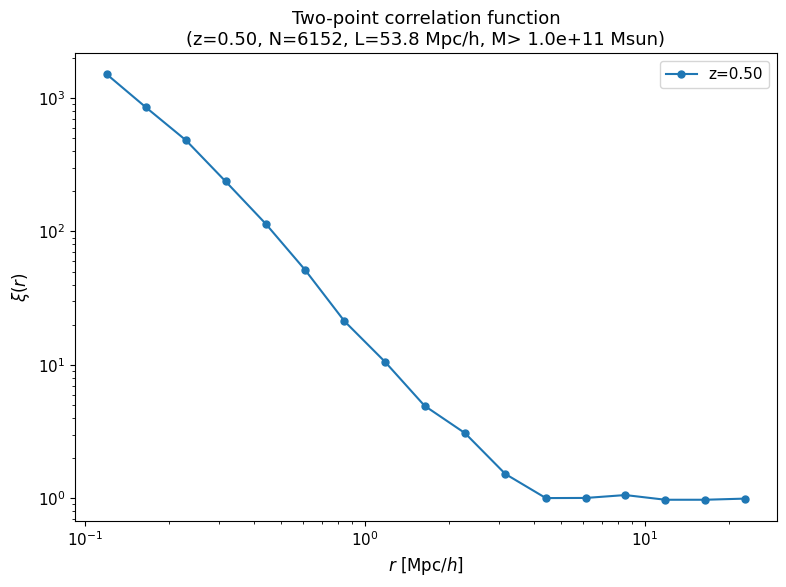

In [3]:
# Plot the correlation function
if result is not None:
    r = result['r'].to_numpy()
    xi = result['xi'].to_numpy()
    z = result.attrs.get('z')
    ngal = result.attrs.get('ngal')
    boxsize = result.attrs.get('boxsize')
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot only positive, finite values on log-log scale
    mask = (xi > 0) & np.isfinite(xi)
    ax.loglog(r[mask], xi[mask], 'o-', markersize=5, label=f'z={z:.2f}')
    
    ax.set_xlabel(r'$r$ [Mpc/$h$]', fontsize=12)
    ax.set_ylabel(r'$\xi(r)$', fontsize=12)
    ax.set_title(f'Two-point correlation function\n(z={z:.2f}, N={ngal}, L={boxsize:.1f} Mpc/h, M> {mhalo_min:.1e} Msun)', fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

## 2PCF for one subvolume across multiple redshifts (overlay)

In [4]:
# Compute correlation for multiple redshifts
iz_nums = [100, 120, 142, 176, 207]
example_ivol = 100

print("Computing 2PCF evolution with redshift")
print(f"Snapshots: {[f'iz{iz}' for iz in iz_nums]}")
print(f"Subvolume: {example_ivol}\n")

results = []
for iz_num in iz_nums:
    iz_path = str(base_dir / f'iz{iz_num}')
    res = correlation_given_redshift_and_subvolume(
        iz_path,
        example_ivol,
        rbins=rbins,
        nthreads=4,
        mhalo_min=mhalo_min,
    )
    if res is not None:
        res.attrs['iz'] = f'iz{iz_num}'
        results.append(res)
        print(f"✓ iz{iz_num}: z={res.attrs.get('z'):.3f}, N={res.attrs.get('ngal')}")
    else:
        print(f"✗ iz{iz_num}: failed")

if len(results) > 0:
    print(f"\nSuccessfully computed {len(results)}/{len(iz_nums)} snapshots")
else:
    print("No successful computations")

Computing 2PCF evolution with redshift
Snapshots: ['iz100', 'iz120', 'iz142', 'iz176', 'iz207']
Subvolume: 100

✗ iz100: failed
✗ iz120: failed
✗ iz142: failed


Traceback (most recent call last):
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/correlation.py", line 169, in correlation_given_redshift_and_subvolume
    pos, z_val = _load_positions_from_hdf5(iz_path, ivol, centrals_only=centrals_only, mhalo_min=mhalo_min)
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/correlation.py", line 32, in _load_positions_from_hdf5
    return read_galaxy_positions(
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/utils/read_galaxies.py", line 184, in read_galaxy_positions
    arrays, meta = read_galaxy_arrays(
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/utils/read_galaxies.py", line 67, in read_galaxy_arrays
    raise FileNotFoundError(f"Missing or unreadable galaxies.hdf5 at {iz_path}/ivol{ivol}")
FileNotFoundError: Missing or unreadable galaxies.hdf5 at /cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14/iz1

✓ iz176: z=1.007, N=5558
✓ iz207: z=0.496, N=6152

Successfully computed 2/5 snapshots


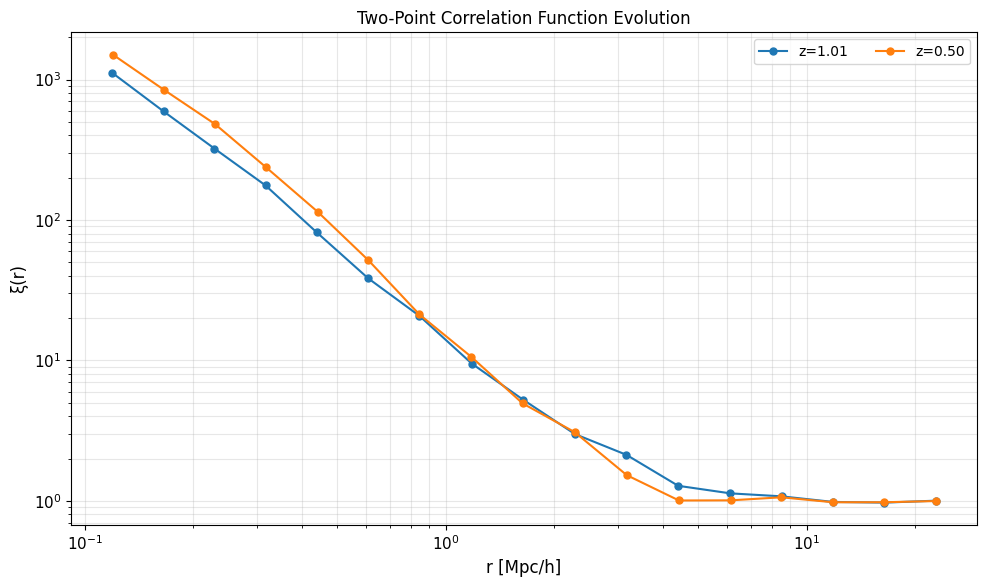

In [6]:
# Plot correlation evolution with redshift
if len(results) > 0:
    plt.figure(figsize=(10, 6))
    
    for i, res in enumerate(results):
        r = res['r'].to_numpy()
        xi = res['xi'].to_numpy()
        z = res.attrs.get('z')
        iz = res.attrs.get('iz')
        label = f"z={z:.2f}" if z is not None else (iz if iz is not None else f"snapshot {i}")
        plt.loglog(r, xi, 'o-', label=label, markersize=5, linewidth=1.5)
    
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    plt.title('Two-Point Correlation Function Evolution', fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.legend(fontsize=10, ncol=2)
    plt.tight_layout()
    plt.show()

## Average 2PCF over multiple redshifts for one subvolume

In [7]:
# Average over redshifts for a single subvolume
example_ivol = 40
iz_nums = [100, 120, 142, 176, 207]

avg_result = avg_correlation_given_subvolume_and_redshifts(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    base_dir=str(base_dir),
    mhalo_min=mhalo_min,
 )

if avg_result is not None:
    print(f"✓ Data computed: averaged over {len(iz_nums)} redshifts for ivol {example_ivol}")
    print("First 5 (r, xi, xi_std):")
    r = avg_result['r'].to_numpy()
    xi = avg_result['xi'].to_numpy()
    xi_std = avg_result['xi_std'].to_numpy()
    for i in range(5):
        print(f"{r[i]:10.3f}  {xi[i]:12.6e}  {xi_std[i]:12.6e}")

✓ Data computed: averaged over 5 redshifts for ivol 40
First 5 (r, xi, xi_std):
     0.120  1.314449e+03  3.274420e+02
     0.170  6.572192e+02  2.448525e+02
     0.219  3.359889e+02  1.542907e+02
     0.323  1.881987e+02  9.464649e+01
     0.432  1.080618e+02  5.218208e+01


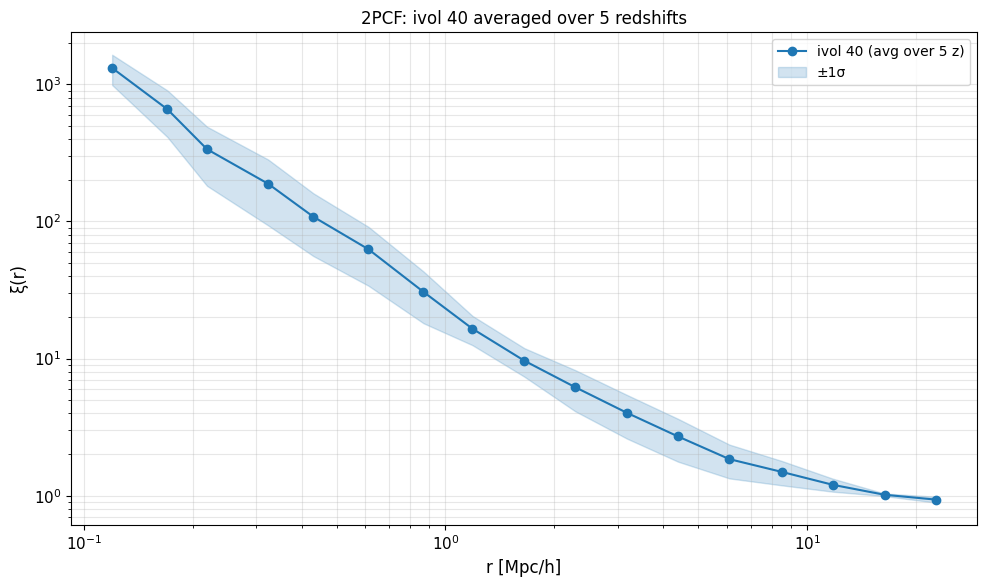

In [8]:
# Plot average correlation over redshifts
if avg_result is not None:
    r = avg_result['r'].to_numpy()
    xi = avg_result['xi'].to_numpy()
    xi_std = avg_result['xi_std'].to_numpy()
    
    plt.figure(figsize=(10, 6))
    plt.loglog(r, xi, 'o-', color='tab:blue', label=f'ivol {example_ivol} (avg over {len(iz_nums)} z)')
    plt.fill_between(r, xi - xi_std, xi + xi_std, color='tab:blue', alpha=0.2, label='±1σ')
    
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    plt.title(f'2PCF: ivol {example_ivol} averaged over {len(iz_nums)} redshifts', fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## 2PCF averaged over multiple subvolumes at different redshifts

In [9]:
# Average correlation across multiple subvolumes for each redshift
iz_nums = [100, 120, 142, 176, 207]
example_ivols = [40, 60]  # Two subvolumes for averaging
results_multi = []
for iz_num in iz_nums:
    result = avg_correlation_given_redshift_and_subvolumes(
        iz_num=iz_num,
        ivols=example_ivols,
        rbins=rbins,
        nthreads=4,
        base_dir=str(base_dir),
        mhalo_min=mhalo_min,
    )
    if result is not None:
        results_multi.append(result)
        print(f"✓ iz{iz_num}: z={result.attrs.get('z'):.2f}, avg over {result.attrs.get('n_used')} ivols")

✓ iz100: z=4.30, avg over 2 ivols
✓ iz120: z=3.05, avg over 2 ivols
✓ iz142: z=2.00, avg over 2 ivols
✓ iz176: z=1.01, avg over 2 ivols
✓ iz207: z=0.50, avg over 2 ivols


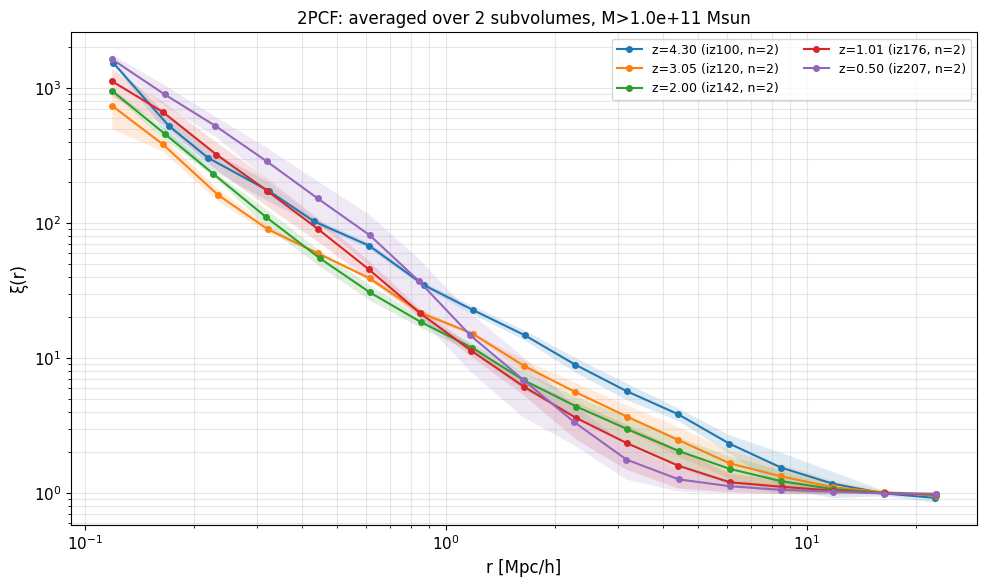

In [11]:
# Plot average correlation functions across redshift (multi-subvolume)
if len(results_multi) > 0:
    plt.figure(figsize=(10, 6))
    
    for i, res in enumerate(results_multi):
        r = res['r'].to_numpy()
        xi = res['xi'].to_numpy()
        xi_std = res['xi_std'].to_numpy()
        z = res.attrs.get('z')
        iz = res.attrs.get('iz')
        n_used = res.attrs.get('n_used')
        label = f"z={z:.2f} ({iz}, n={n_used})" if z is not None else f"{iz}"
        plt.loglog(r, xi, 'o-', label=label, markersize=4)
        plt.fill_between(r, xi - xi_std, xi + xi_std, alpha=0.15)
    
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    plt.title(f'2PCF: averaged over {len(example_ivols)} subvolumes, M>{mhalo_min:.1e} Msun', fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()